# Hypothesis Testing and Statistical Analysis: CO2 Emissions and Economic Growth


# Introduction

This notebook presents the statistical analysis conducted as part of the *world_carbon_money_heat_analysis* project. The primary aim of this analysis is to investigate whether economic growth can be decoupled from CO2 emissions, a key question in understanding the relationship between development and environmental sustainability.

Using a merged dataset derived from multiple sources, including CO2 emissions, GDP per capita, energy production, and population data, this notebook applies a range of statistical techniques to explore patterns and relationships across countries and over time.

To address this objective, the following hypotheses are tested:

- **H1:** GDP per capita is positively associated with CO2 emissions per capita  
- **H2:** Renewable energy is negatively associated with CO2 emissions per capita  
- **H3:** CO2 emissions per capita decreased between 2019 and 2020  
- **H4:** CO2 emissions per capita differ across income groups  

Each hypothesis is evaluated using an appropriate statistical method, including linear regression, multiple regression, paired t-tests, and one-way ANOVA. These methods are selected based on the structure of the data and the nature of each research question.

The findings from this analysis aim to provide evidence-based insights into whether economic development is associated with increased emissions, and whether transitions towards renewable energy contribute to reducing environmental impact.

---

# Import Libraries

In [ ]:
# Import the libraries required for data handling, statistical testing, and modelling.
# These imports are included now so that the notebook structure is ready once the merged dataset is available.

# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing
from scipy.stats import ttest_rel, f_oneway

# Regression modelling
import statsmodels.api as sm

---

# Load data


In [28]:
# Load final merged dataset

from pathlib import Path
import pandas as pd

# Set project root
project_root = Path.cwd().parent if Path.cwd().name == "jupyter_notebooks" else Path.cwd()

# Path to final merged dataset
data_path = project_root / "data" / "processed" / "04_df_all_data_1990_2024.csv"

# Load dataset
df_merged = pd.read_csv(data_path)

print("Merged dataset loaded successfully.")
print(f"Dataset shape: {df_merged.shape}")
display(df_merged.head())

Merged dataset loaded successfully.
Dataset shape: (7473, 16)


,country_code_iso3,country_name_iso3,year,co2_pc,population,gdp_constant_ppp_pc,degc,other_renewables,bioenergy,solar,wind,hydropower,nuclear,oil,gas,coal
0,AFG,Afghanistan,1990,0.168054,12045664.0,NaN,13.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,1991,0.156411,12238879.0,NaN,12.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AFG,Afghanistan,1992,0.111609,13278983.0,NaN,12.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AFG,Afghanistan,1993,0.099506,14943175.0,NaN,12.71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AFG,Afghanistan,1994,0.089462,16250800.0,NaN,12.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

# Feature engineering

Before statistical testing begins, additional derived variables will be created from the merged dataset.

These include:

- total renewable energy
- total fossil fuel energy

These summary variables simplify the analysis and make it easier to test the relationship between energy composition and CO2 emissions.

In [29]:
# Feature engineering


# Create a working copy.

df_merged = df_merged.copy()


# Rename key columns for easier analysis.

df_merged = df_merged.rename(columns={
    "country_name_iso3": "country",
    "co2_pc": "co2_per_capita",
    "gdp_constant_ppp_pc": "gdp_per_capita"
})


# Convert important columns to numeric.

numeric_cols = [
    "year", "co2_per_capita", "population", "gdp_per_capita", "degc",
    "other_renewables", "bioenergy", "solar", "wind", "hydropower",
    "nuclear", "oil", "gas", "coal"
]

for col in numeric_cols:
    if col in df_merged.columns:
        df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")


# Create renewable energy variable.

df_merged["renewables"] = (
    df_merged["solar"].fillna(0) +
    df_merged["wind"].fillna(0) +
    df_merged["hydropower"].fillna(0) +
    df_merged["bioenergy"].fillna(0) +
    df_merged["other_renewables"].fillna(0)
)


# Create fossil fuel variable.
df_merged["fossil_fuels"] = (
    df_merged["coal"].fillna(0) +
    df_merged["gas"].fillna(0) +
    df_merged["oil"].fillna(0)
)


# Create income groups ONLY where GDP exists (to avoid misclassification of missing data).

# Only use rows where GDP exists.

gdp_valid = df_merged[df_merged["gdp_per_capita"].notna()]

# Create income groups on valid GDP rows.

income_groups = pd.qcut(
    gdp_valid["gdp_per_capita"],
    q=4,
    labels=["Low income", "Lower-middle income", "Upper-middle income", "High income"]
)

# Assign back to main dataframe.

df_merged.loc[gdp_valid.index, "income_group"] = income_groups

print("Income groups successfully created.")


# Display the first few rows of the dataset with income groups to verify.

df_merged[df_merged["income_group"].notna()][[
    "country", "year", "co2_per_capita", "gdp_per_capita", "renewables", "fossil_fuels", "income_group"
]].head()

Income groups successfully created.


,country,year,co2_per_capita,gdp_per_capita,renewables,fossil_fuels,income_group
10,Afghanistan,2000,0.052017,1617.826475,0.31,0.17,Low income
11,Afghanistan,2001,0.052706,1454.110782,0.50,0.19,Low income
12,Afghanistan,2002,0.062731,1774.308743,0.56,0.15,Low income
13,Afghanistan,2003,0.068608,1815.928200,0.63,0.28,Low income
14,Afghanistan,2004,0.052513,1776.918207,0.56,0.23,Low income


---

# Data Preparation for Statistical Testing

Before conducting hypothesis testing, rows with missing values in key variables were removed.

This ensures:
- statistical models are valid and reliable,
- comparisons are made on consistent data,
- results are not biased by incomplete observations.

The cleaned dataset (`analysis_df`) is used for all subsequent analysis.

In [30]:
# Create clean dataset for hypothesis testing.


# Purpose: Remove rows with missing values in key variables required for statistical analysis.

analysis_df = df_merged.dropna(subset=[
    "co2_per_capita",
    "gdp_per_capita",
    "renewables"
]).copy()

print("Clean dataset created for analysis.")
print(f"Dataset shape: {analysis_df.shape}")

display(analysis_df.head())

Clean dataset created for analysis.
Dataset shape: (6675, 19)


,country_code_iso3,country,year,co2_per_capita,population,gdp_per_capita,degc,other_renewables,bioenergy,solar,wind,hydropower,nuclear,oil,gas,coal,renewables,fossil_fuels,income_group
10,AFG,Afghanistan,2000,0.052017,20130334.0,1617.826475,13.59,0.0,0.0,0.0,0.0,0.31,0.0,0.17,0.0,0.00,0.31,0.17,Low income
11,AFG,Afghanistan,2001,0.052706,20284303.0,1454.110782,13.93,0.0,0.0,0.0,0.0,0.50,0.0,0.15,0.0,0.04,0.50,0.19,Low income
12,AFG,Afghanistan,2002,0.062731,21378123.0,1774.308743,13.78,0.0,0.0,0.0,0.0,0.56,0.0,0.11,0.0,0.04,0.56,0.15,Low income
13,AFG,Afghanistan,2003,0.068608,22733053.0,1815.928200,13.27,0.0,0.0,0.0,0.0,0.63,0.0,0.19,0.0,0.09,0.63,0.28,Low income
14,AFG,Afghanistan,2004,0.052513,23560656.0,1776.918207,13.92,0.0,0.0,0.0,0.0,0.56,0.0,0.17,0.0,0.06,0.56,0.23,Low income


# Hypothesis 1: GDP per Capita and CO2 Emissions per Capita

A key question in climate and economic research is whether economic growth can occur without a corresponding increase in carbon emissions. This hypothesis investigates the relationship between GDP per capita and CO2 emissions per capita to assess whether higher levels of economic development are associated with greater environmental impact.

To examine this relationship, a **simple linear regression model** is used, where GDP per capita is treated as the independent variable and CO2 emissions per capita as the dependent variable. This approach allows the analysis to quantify both the direction and strength of the relationship between economic growth and emissions.

## Hypothesis:

- **H0 (Null) :** No significant relationship between GDP per capita and CO2 emissions.
- **H1 (Alternative) :** GDP per capita is positively associated with CO2 emissions.

In [31]:
# Hypothesis 1: GDP per capita vs CO2 emissions per capita


# Purpose: To test whether higher economic output (GDP per capita) is associated with higher CO2 emissions per capita.


# Step 1: Select relevant variables.

h1_df = analysis_df[["gdp_per_capita", "co2_per_capita"]].dropna()

print(f"Number of observations: {len(h1_df)}")


# Step 2: Define variables.

X = h1_df["gdp_per_capita"]  # Independent variable
y = h1_df["co2_per_capita"]  # Dependent variable


# Step 3: Add constant (intercept). 

import statsmodels.api as sm
X = sm.add_constant(X)

# Step 4: Fit model.

model_h1 = sm.OLS(y, X).fit()

# Step 5: Output results.

print(model_h1.summary())

Number of observations: 6675
                            OLS Regression Results                            
Dep. Variable:         co2_per_capita   R-squared:                       0.329
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     3270.
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:52:34   Log-Likelihood:                -22062.
No. Observations:                6675   AIC:                         4.413e+04
Df Residuals:                    6673   BIC:                         4.414e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          

## Interpretation of Results (H1)

The regression analysis examined the relationship between GDP per capita and CO2 emissions per capita.

The coefficient for GDP per capita is positive (0.0002), indicating that higher levels of economic output are associated with higher CO2 emissions per capita.

The p-value is less than 0.05 (p = 0.000), demonstrating that this relationship is statistically significant. Therefore, there is strong evidence to reject the null hypothesis.

The R-squared value of 0.329 suggests that approximately 32.9% of the variation in CO2 emissions per capita can be explained by GDP per capita alone. This indicates a moderate relationship, suggesting that while economic growth is an important factor, other variables also contribute to emissions levels.

While the model is statistically significant, the large condition number suggests potential scaling issues or variability in the data, which may affect numerical stability. However, this does not invalidate the overall findings.

Overall, the results support the hypothesis that GDP per capita is positively associated with CO2 emissions per capita.

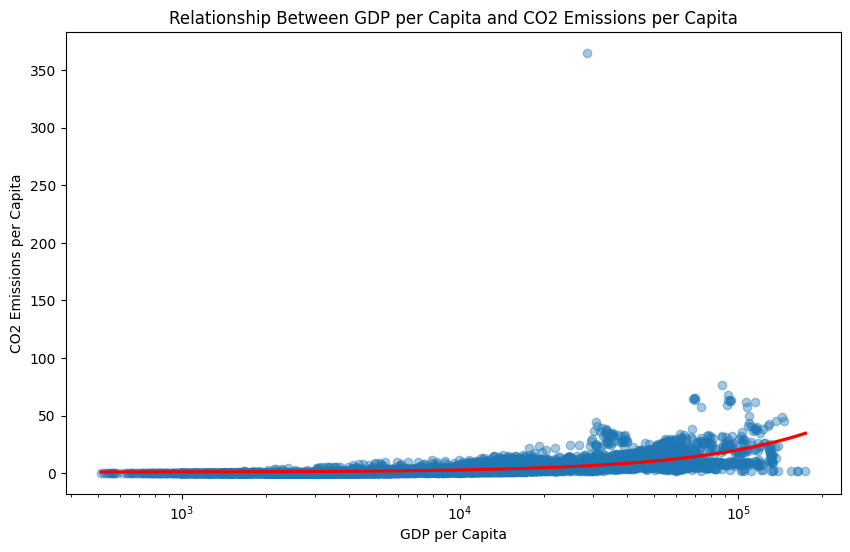

In [32]:
# Visualisation: GDP per capita vs CO2 emissions per capita


# Purpose: To visually explore the relationship between economic growth (GDP per capita) and environmental impact (CO2 emissions per capita).
# This supports the regression analysis by providing a graphical representation of the relationship.


# Method: A scatter plot is used to display individual country-year observations. A regression line is added to highlight the overall trend in the data.


# Set figure size for readability.

plt.figure(figsize=(10, 6))


# Create scatter plot with regression line.

sns.regplot(
    data=h1_df,
    x="gdp_per_capita",
    y="co2_per_capita",
    
    # Make points semi-transparent to reduce overlap.
    scatter_kws={"alpha": 0.4},
    
    # Highlight regression line clearly.
    line_kws={"color": "red"}
)


# Add descriptive title and axis labels.

plt.title("Relationship Between GDP per Capita and CO2 Emissions per Capita")
plt.xlabel("GDP per Capita")
plt.ylabel("CO2 Emissions per Capita")


# Use logarithmic scale to improve visibility (GDP values can vary widely across countries).

plt.xscale("log")


# Display the plot.

plt.show()


## Visual Interpretation

The scatter plot illustrates the relationship between GDP per capita and CO2 emissions per capita across countries and years.

An overall positive trend is observed, as indicated by the upward-sloping regression line. This suggests that higher levels of economic output are generally associated with higher emissions.

However, the data is unevenly distributed, with a large concentration of observations at lower GDP levels and a smaller number of countries with very high GDP and emissions. This results in a right-skewed distribution.

Several outliers are also present, where certain observations exhibit disproportionately high emissions. These may reflect countries with high energy consumption or reliance on carbon-intensive industries.

Despite this variability, the overall trend supports the regression findings, reinforcing the conclusion that GDP per capita is positively associated with CO2 emissions per capita.

## Summary of Findings (H1)

The analysis found a statistically significant positive relationship between GDP per capita and CO2 emissions per capita. Both the regression results and visualisation indicate that higher levels of economic output are associated with increased emissions.

The model explains approximately 32.9% of the variation in emissions, suggesting that while economic growth is an important factor, other variables also influence CO2 levels.

Overall, these findings support the hypothesis that economic growth is linked to higher carbon emissions, indicating that, within this dataset, economic development has not been fully decoupled from environmental impact.

---

# Hypothesis 2: Renewable Energy and CO2 Emissions per Capita

A key aspect of decoupling economic growth from environmental impact is the transition towards renewable energy sources. This hypothesis examines whether increased use of renewable energy is associated with lower CO2 emissions per capita, helping to assess whether cleaner energy adoption contributes to reducing emissions.

To evaluate this relationship, a **multiple linear regression model** is used. Renewable energy is included as the main independent variable, while GDP per capita is incorporated as a control variable to account for differences in economic development. CO2 emissions per capita is treated as the dependent variable. This approach allows the analysis to isolate the effect of renewable energy on emissions while considering the influence of economic activity.


## Hypothesis

- **H0 (Null):** Renewable energy is not significantly associated with CO2 emissions per capita.
- **H2 (Alternative):** Renewable energy is negatively associated with CO2 emissions per capita.



In [33]:
# H2: Multiple regression: Renewables + GDP -> CO2 emissions per capita. 


# Purpose: To test whether renewable energy is associated with lower CO2 emissions, while controlling for GDP.


# Step 1: Select relevant variables and remove missing values.

h2_df = analysis_df[[
    "renewables",
    "gdp_per_capita",
    "co2_per_capita"
]].dropna()

print(f"Number of observations used for H2: {len(h2_df)}")


# Step 2: Define independent and dependent variables.

X = h2_df[["renewables", "gdp_per_capita"]]  # predictors
y = h2_df["co2_per_capita"]                 # outcome


# Step 3: Add constant (intercept).

X = sm.add_constant(X)


# Step 4: Fit regression model.

model_h2 = sm.OLS(y, X).fit()


# Step 5: Display results.

print(model_h2.summary())

Number of observations used for H2: 6675
                            OLS Regression Results                            
Dep. Variable:         co2_per_capita   R-squared:                       0.329
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     1635.
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:52:35   Log-Likelihood:                -22062.
No. Observations:                6675   AIC:                         4.413e+04
Df Residuals:                    6672   BIC:                         4.415e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
con

## Interpretation of Results (H2)

The multiple regression analysis examined the relationship between renewable energy and CO2 emissions per capita, while controlling for GDP per capita.

The coefficient for renewable energy is positive (0.0006), but the p-value (0.424) is greater than 0.05, indicating that the relationship is not statistically significant. This suggests that there is no strong evidence that renewable energy is associated with lower CO2 emissions in this dataset.

In contrast, GDP per capita remains a statistically significant predictor (p = 0.000), with a positive coefficient, reinforcing the finding from H1 that economic growth is associated with higher emissions.

Overall, renewable energy does not show a statistically significant independent association with CO2 emissions in this model

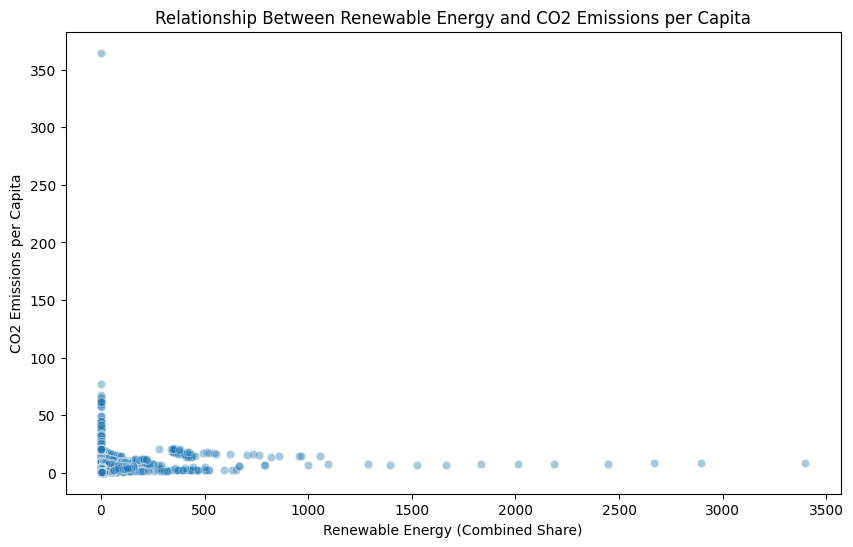

In [34]:
# Visualisation: Renewable Energy vs CO2 Emissions per Capita.


# Purpose: To visually explore whether higher levels of renewable energy are associated with lower CO2 emissions per capita.
# This helps provide an intuitive understanding of the relationship before interpreting the regression results.


# Method: A scatter plot is used to display individual country-year observations.
# Each point represents one country in a given year.
# The transparency (alpha) is reduced to help visualise dense areas where many points overlap.


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=h2_df,
    x="renewables",
    y="co2_per_capita",
    alpha=0.4
)

# Add descriptive title and labels for clarity.

plt.title("Relationship Between Renewable Energy and CO2 Emissions per Capita")
plt.xlabel("Renewable Energy (Combined Share)")
plt.ylabel("CO2 Emissions per Capita")


# Display the plot.

plt.show()

## Visual Interpretation

The scatter plot shows the relationship between renewable energy and CO2 emissions per capita.

The data points are widely dispersed, with no clear downward trend. This indicates that higher levels of renewable energy are not consistently associated with lower emissions.

A large concentration of observations is visible at lower levels of both renewable energy and emissions, while a small number of outliers exhibit unusually high values.

Overall, the visual pattern supports the regression results, suggesting that renewable energy does not have a strong independent effect on reducing CO2 emissions within this dataset.

## Summary of Findings (H2)

The results show no statistically significant relationship between renewable energy and CO2 emissions per capita when controlling for GDP per capita. While renewable energy is theoretically expected to reduce emissions, the findings suggest that its impact is not sufficient to offset the effects of economic growth within this dataset.

GDP per capita remains a strong and significant predictor of emissions, reinforcing the conclusion that economic activity continues to drive carbon output.

These findings indicate that, despite the presence of renewable energy, there is limited evidence of effective decoupling between economic growth and environmental impact. This suggests that broader structural changes, beyond increases in renewable energy alone, may be required to achieve meaningful emissions reductions.

---

# Hypothesis 3: Change in CO2 Emissions per Capita from 2019 to 2020

Global events can significantly affect emissions patterns, particularly when they disrupt economic activity, transport, and energy demand. This hypothesis examines whether CO2 emissions per capita decreased between 2019 and 2020, a period strongly associated with the global disruption caused by the COVID-19 pandemic.

To test this, a **paired t-test** is used to compare CO2 emissions per capita for the same countries across the two years. This method is appropriate because it evaluates whether the mean difference between paired observations is statistically significant.

## Hypothesis
- **H0 (Null):** There is no significant difference in CO2 emissions per capita between 2019 and 2020.
- **H3 (Alternative):** CO2 emissions per capita decreased from 2019 to 2020.

In [ ]:
# H3: Paired t-test for CO2 emissions in 2019 vs 2020


# Purpose: To test whether CO2 emissions per capita decreased between 2019 and 2020 for the same countries.
# This helps assess whether there was a significant short-term drop in emissions during the period associated with major global disruption.


# Method: A paired t-test is used because the analysis compares the same countries across two different years.
# This requires reshaping the data so that each country has one value for 2019 and one value for 2020.


# Step 1: Keep only the variables needed for this hypothesis.

h3_df = analysis_df[["country", "year", "co2_per_capita"]].copy()


# Step 2: Filter the data to include only 2019 and 2020.

h3_df = h3_df[h3_df["year"].isin([2019, 2020])]


# Step 3: Reshape the data so each country has one row with separate columns for 2019 and 2020 emissions.

h3_pivot = h3_df.pivot_table(
    index="country",
    columns="year",
    values="co2_per_capita",
    aggfunc="mean"
)


# Step 4: Remove countries that do not have values for both years.

h3_pivot = h3_pivot.dropna(subset=[2019, 2020])

print(f"Number of matched country pairs used for H3: {len(h3_pivot)}")
display(h3_pivot.head())


# Step 5: Run the paired t-test.

t_stat, p_value = ttest_rel(h3_pivot[2019], h3_pivot[2020])


# Step 6: Calculate mean emissions for each year.

mean_2019 = h3_pivot[2019].mean()
mean_2020 = h3_pivot[2020].mean()
mean_difference = mean_2020 - mean_2019


# Step 7: Print the results clearly.

print(f"Mean CO2 emissions per capita in 2019: {mean_2019:.4f}")
print(f"Mean CO2 emissions per capita in 2020: {mean_2020:.4f}")
print(f"Mean difference (2020 - 2019): {mean_difference:.4f}")
print(f"Paired t-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Number of matched country pairs used for H3: 195


year,2019,2020
country,,
Afghanistan,0.274727,0.284590
Albania,1.712481,1.693982
Algeria,4.213579,3.885795
Andorra,6.418658,4.876055
Angola,0.686012,0.494732


Mean CO2 emissions per capita in 2019: 4.8061
Mean CO2 emissions per capita in 2020: 4.4746
Mean difference (2020 - 2019): -0.3315
Paired t-test statistic: 6.1125
P-value: 0.0000


## Interpretation of Results (H3)

The paired t-test compared CO2 emissions per capita for the same countries in 2019 and 2020.

The mean CO2 emissions per capita decreased from 4.8061 in 2019 to 4.4746 in 2020, resulting in an average reduction of 0.3315. This indicates that emissions were lower in 2020 across the matched countries.

The p-value is less than 0.05 (p = 0.0000), indicating that this decrease is statistically significant. Therefore, the null hypothesis can be rejected.

Overall, the results provide strong evidence that CO2 emissions per capita decreased between 2019 and 2020.

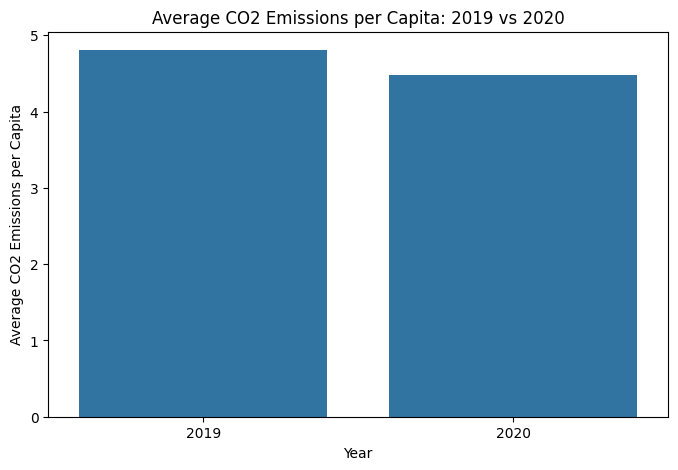

In [36]:
# Visualisation: Average CO2 emissions per capita (2019 vs 2020).


# Purpose: To compare average CO2 emissions per capita between 2019 and 2020 in order to visually assess whether emissions decreased during this period.
# This supports the paired t-test by providing a simple, intuitive comparison of the mean values across the two years.


# Method: A bar chart is used to display the average CO2 emissions per capita for each year.
# Each bar represents the mean emissions across all matched countries included in the paired analysis.
# This allows for an easy visual comparison of changes in emissions between the two time points.


# Step 1: Create a summary dataframe for plotting.
# This contains the mean CO2 emissions for each year.

h3_summary = pd.DataFrame({
    "year": ["2019", "2020"],
    "mean_co2_per_capita": [mean_2019, mean_2020]
})


# Step 2: Set up the figure size for readability.

plt.figure(figsize=(8, 5))


# Step 3: Create the bar plot.

sns.barplot(
    data=h3_summary,
    x="year",
    y="mean_co2_per_capita"
)


# Step 4: Add clear titles and labels.

plt.title("Average CO2 Emissions per Capita: 2019 vs 2020")
plt.xlabel("Year")
plt.ylabel("Average CO2 Emissions per Capita")


# Step 5: Display the plot.

plt.show()

## Visual Interpretation

The bar chart shows a decrease in average CO2 emissions per capita from 2019 to 2020.

The height of the 2020 bar is clearly lower than that of 2019, indicating a reduction in emissions across the matched countries. This visual pattern aligns with the results of the paired t-test, which confirmed that the decrease is statistically significant.

Overall, the chart provides a clear and intuitive illustration of the decline in emissions between the two years.

## Summary of Findings (H3)

The results show a statistically significant reduction in CO2 emissions per capita between 2019 and 2020 across the sampled countries.

The observed decrease in average emissions suggests that the global disruption in 2020 led to a measurable decline in carbon output. This highlights the strong link between economic activity and emissions levels.

However, the reduction appears to be driven by short-term external factors rather than structural changes in energy systems. As such, the findings provide limited evidence of sustained decoupling between economic growth and environmental impact.

---

# Hypothesis 4: CO2 Emissions per Capita by Income Group

Differences in economic development levels may influence patterns of carbon emissions across countries. This hypothesis examines whether CO2 emissions per capita differ across income groups derived from GDP per capita.

To evaluate this, a **one-way ANOVA test** is used to compare mean CO2 emissions across multiple income groups. This method is appropriate because it determines whether there are statistically significant differences between the means of more than two independent groups.

## Hypothesis
- **H0 (Null):** There is no significant difference in CO2 emissions per capita across income groups.
- **H4 (Alternative):** There are significant differences in CO2 emissions per capita across income groups.


In [37]:
# H4: One-way ANOVA for income groups


# Purpose: To test whether mean CO2 emissions per capita differ across income groups.


# Method: A one-way ANOVA is used because:
# - income_group is a categorical variable (4 groups)
# - CO2 emissions is continuous


# Step 1: Select relevant data.

h4_df = analysis_df[["income_group", "co2_per_capita"]].dropna()


# Step 2: Identify unique income groups.

groups = h4_df["income_group"].unique()
print("Income groups:", groups)


# Step 3: Create a list of CO2 values for each group.

group_data = [
    h4_df[h4_df["income_group"] == group]["co2_per_capita"]
    for group in groups
]


# Step 4: Run ANOVA test.

f_stat, p_value = f_oneway(*group_data)


# Step 5: Display results.

print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")


# Step 6: Show group means.

print("\nMean CO2 emissions per capita by income group:")
display(h4_df.groupby("income_group")["co2_per_capita"].mean().sort_values())

Income groups: ['Low income', 'Lower-middle income', 'Upper-middle income', 'High income']
Categories (4, str): ['Low income' < 'Lower-middle income' < 'Upper-middle income' < 'High income']
ANOVA F-statistic: 1020.8529
P-value: 0.0000

Mean CO2 emissions per capita by income group:


income_group
Low income              0.426796
Lower-middle income     1.983124
Upper-middle income     5.379542
High income            12.167767
Name: co2_per_capita, dtype: float64

## Interpretation of Results (H4)

The one-way ANOVA test examined whether CO2 emissions per capita differ across income groups.

The results show a statistically significant difference between groups (F = 1020.85, p = 0.0000), indicating that the null hypothesis can be rejected.

Mean CO2 emissions increase substantially across income levels, from 0.43 in low-income countries to 12.17 in high-income countries. This demonstrates a clear pattern in which higher-income countries tend to have higher emissions per capita.

While ANOVA confirms significant differences between groups overall, the group means suggest a clear upward pattern in emissions from low-income to high-income categories.

Overall, the findings suggest that economic development is strongly associated with differences in emissions levels across countries.

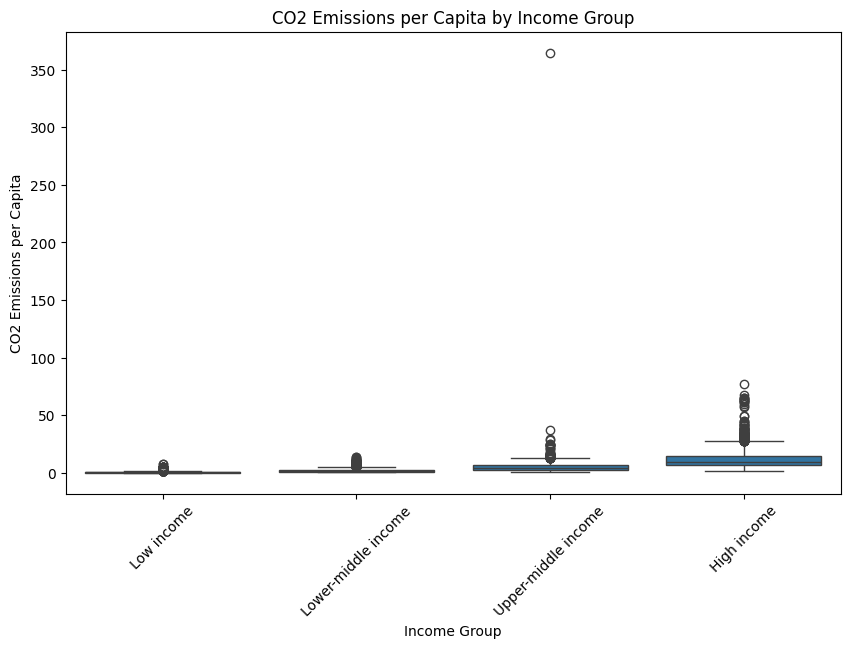

In [38]:
# Visualisation: CO2 emissions per capita by income group


# Purpose: To compare the distribution of CO2 emissions per capita across different income groups.
# This helps visually assess whether emissions vary by economic development level, supporting the ANOVA results.


# Method: A boxplot is used to display the distribution of CO2 emissions within each income group.
# Each box shows:
# - The median (central line)
# - The interquartile range (box)
# - The spread of the data (whiskers)
# - Potential outliers (points)
# This allows for comparison of both central tendency and variability across groups.


# Step 1: Set figure size for readability.

plt.figure(figsize=(10, 6))


# Step 2: Create the boxplot.

sns.boxplot(
    data=h4_df,
    x="income_group",
    y="co2_per_capita"
)


# Step 3: Add descriptive title and axis labels.

plt.title("CO2 Emissions per Capita by Income Group")
plt.xlabel("Income Group")
plt.ylabel("CO2 Emissions per Capita")


# Rotate labels for better readability if needed.

plt.xticks(rotation=45)


# Step 4: Display the plot.

plt.show()


## Visual Interpretation

The boxplot shows clear differences in CO2 emissions per capita across income groups.

A strong upward trend is observed, with median emissions increasing from low-income to high-income countries. This indicates that countries with higher levels of economic development tend to produce higher emissions per capita.

The spread of emissions also increases with income level, particularly within high-income countries, suggesting greater variability in emissions among more developed economies.

Several outliers are present, especially in higher income groups, reflecting countries with exceptionally high emissions. However, the overall pattern remains consistent.

While a clear relationship is observed, the variation within income groups suggests that factors such as energy mix, policy, and efficiency also influence emissions beyond income level alone.

In sum, this visual evidence strongly supports the ANOVA results, confirming that CO2 emissions differ significantly across income groups.

---

# Summary of Hypothesis Testing Results

| Hypothesis | Test Used | Key Finding | Supported |
|-----------|----------|------------|-----------|
| H1: GDP per capita is positively associated with CO2 emissions | Linear Regression | Significant positive relationship between GDP and emissions (p < 0.05) | ✅ Yes |
| H2: Renewable energy is negatively associated with CO2 emissions | Multiple Regression | No statistically significant relationship between renewables and emissions (p > 0.05) | ❌ No |
| H3: CO2 emissions decreased from 2019 to 2020 | Paired t-test | Significant decrease in emissions between 2019 and 2020 (p < 0.05) | ✅ Yes |
| H4: CO2 emissions differ by income group | One-way ANOVA | Significant differences in emissions across income groups (p < 0.05) | ✅ Yes |

---

# Final Conclusion

This analysis explored whether economic growth can be decoupled from CO2 emissions by examining the relationships between GDP, renewable energy, time-based changes, and income groups.

The results show a consistent and significant positive relationship between GDP per capita and CO2 emissions per capita, indicating that economic growth remains strongly linked to increased emissions. This finding is reinforced by the analysis across income groups, where higher-income countries exhibit substantially higher emissions levels.

Although renewable energy is often expected to reduce emissions, the analysis found no statistically significant independent effect when controlling for GDP. This suggests that increases in renewable energy alone may not be sufficient to offset the impact of economic growth, particularly if overall energy demand continues to rise.

The temporary reduction in emissions observed between 2019 and 2020 highlights that emissions can decrease under conditions of reduced economic activity. However, this appears to reflect short-term disruption rather than a sustained structural change.

Overall, the findings provide limited evidence of decoupling between economic growth and CO2 emissions within this dataset. Instead, they suggest that emissions remain closely tied to economic activity, and that achieving meaningful reductions may require broader systemic changes beyond the expansion of renewable energy alone. These findings highlight the complexity of balancing economic development with environmental sustainability, emphasising the need for more comprehensive strategies to achieve long-term emissions reduction.